## Imports and Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from datetime import datetime, timedelta
import spiceypy as spice
from astroquery.jplhorizons import Horizons
from astropy.time import Time
import os

In [2]:
import warnings
warnings.filterwarnings('ignore')

# Plotting configuration
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True

plot_dir = '../../data_output/artemis/plots'
os.makedirs(plot_dir, exist_ok=True)

### Constants

#### Physical Constants

In [3]:
# Gravitational parameter MU = G*M
MU_EARTH = 398600.4418       # Earth gravitational parameter [km^3/s^2]
MU_MOON = 4902.8001          # Moon gravitational parameter [km^3/s^2]
MU_SUN = 1.32712440018e11    # Sun gravitational parameter [km^3/s^2]

R_EARTH = 6378.137           # Earth equatorial radius [km]
R_MOON = 1737.4              # Moon mean radius [km]

J2_EARTH = 1.08263e-3        # Earth J2 coefficient
J2_MOON = 2.027e-4           # Moon J2 coefficient

G0 = 9.80665e-3              # Standard gravity [km/s^2] 
AU_KM = 1.495978707e8        # 1 AU in km
C_LIGHT = 299792.458         # Speed of light [km/s]
SOLAR_FLUX = 1367.0          # Solar flux at 1 AU [W/m^2]

#### Mission Constants
https://www.nasa.gov/humans-in-space/space-launch-system/reference-guide/  
https://www.l3harris.com/sites/default/files/2024-07/l3harris-ar-rl10-spec-sheet.pdf

In [4]:
# Interim Cryogenic Propulsion Stage (Upper Stage) - ICPS RL10-B-2 
THRUST_NOMINAL = 110.0       # Nominal thrust [kN] ~110 kilo N from 24,750 lbf
ISP = 465.5                  # Specific impulse [s]
THRUST_RAMP_TIME = 5.0       # Time to reach full thrust [s] (approximate assumption)

# TLI Burn Parameters
# ORION + ICPS
TLI_START_UTC = '2022-11-16T08:17:11'  # TLI ignition
TLI_END_UTC = '2022-11-16T08:35:11'    # Engine cutoff (ECO)
BURN_DURATION = 18 * 60.0              # ~18 minutes [s]
# Flight - Horizons only has data for after ICPS Separation
FLIGHT_START_TIME='2022-11-16T08:47:00'
FLIGHT_END_TIME='2022-11-20T08:47:00' # 4 day cis lunar

# Orion Spacecraft Parameters
ORION_MASS_INITIAL = 26500.0  # Initial mass estimate [kg] (Orion + service module + ICPS residual)
STACK_MASS_INITIAL = 56500.0  # Orion + ICPS Wet Mass [kg] (approximately)
ORION_AREA = 25.0             # Cross-sectional area estimate [m^2]

#### Model specific constants

In [5]:
# Solar Radiation Pressure reflectivity coefficient (approximate assumption)
CR_SRP = 1.5                  

# Compute mass flow rate: mdot = T / (Isp * g0)
MDOT_NOMINAL = (THRUST_NOMINAL * 1000) / (ISP * 9.80665)  # [kg/s] using SI g0

print(f"Nominal mass flow rate: {MDOT_NOMINAL:.2f} kg/s")
print(f"Expected propellant consumption: {MDOT_NOMINAL * BURN_DURATION:.1f} kg over {BURN_DURATION/60:.1f} min")

Nominal mass flow rate: 24.10 kg/s
Expected propellant consumption: 26024.1 kg over 18.0 min


### Load SPICE 

high precision ephemeris data for planets 
- `naif0012.tls` - Leap seconds kernel (UTC - ET conversion)
- `de440s.bsp` - Planetary ephemeris (positions of Earth, Moon, Sun)
- `pck00011.tpc` - Planetary constants (radii, rotation)

In [6]:
def load_spice_kernels():
    kernel_path = "../../data/eclipse/"
    spice.furnsh(kernel_path + "naif0012.tls")  # Leap seconds
    spice.furnsh(kernel_path + "de440s.bsp")    # Planetary ephemeris
    spice.furnsh(kernel_path + "pck00011.tpc")  # Planetary constants


 body_id: NAIF ID of target body (301=Moon, 10=Sun)  
observer_id: NAIF ID of observer (399=Earth)  
et: Ephemeris time [s past J2000]  

In [7]:
def get_body_position_spice(body_id, observer_id, et):
    state, lt = spice.spkgeo(targ=body_id, et=et, ref='J2000', obs=observer_id)
    r = np.array(state[:3]) #[km] (3,)
    return r


#### Run

In [8]:
load_spice_kernels()

### Time Conversion Utilities

JPL Horizons uses UTC, but SPICE operates in Ephemeris Time (ET/TDB)  
There is ~69 seconds diff. due to accumulated leap seconds

In [9]:
def utc_to_et(utc_string):
    return spice.str2et(utc_string) #+ ' UTC'


In [10]:
def et_to_utc(et):
    return spice.et2utc(et, 'ISOC', 0)

In [11]:
et_start = utc_to_et(TLI_START_UTC)
et_end = utc_to_et(TLI_END_UTC)
flight_start = utc_to_et(FLIGHT_START_TIME)
flight_end = utc_to_et(FLIGHT_END_TIME)

print(f"TLI End:   {TLI_END_UTC} UTC -> ET = {et_end:.3f} s past J2000")
print(f"Burn duration: {et_end - et_start:.1f} seconds")
print(f"Flight duration: {flight_end - flight_start:.1f} seconds")

TLI End:   2022-11-16T08:35:11 UTC -> ET = 721859780.183 s past J2000
Burn duration: 1080.0 seconds
Flight duration: 345600.0 seconds


## Visualization Utilities

In [12]:
def plot_time_series(ax, x, y_list, labels=None, colors=None, styles=None, 
                     title="", xlabel="Time [hours]", ylabel="", yscale='linear', 
                     hlines=None, vlines=None):
    # Set defaults 
    if labels is None: labels = [None] * len(y_list)
    if colors is None: colors = [None] * len(y_list)
    if styles is None: styles = ['-'] * len(y_list)
        
    # Plot all lines
    for y, label, color, style in zip(y_list, labels, colors, styles):
        ax.plot(x, y, linestyle=style, color=color, label=label, linewidth=2)
        
    # Add optional horizontal/vertical lines
    if hlines:
        for y_val, c, ls, lab in hlines:
            ax.axhline(y_val, color=c, linestyle=ls, linewidth=1.5, label=lab)
    if vlines:
        for x_val, c, ls, alpha in vlines:
            ax.axvline(x_val, color=c, linestyle=ls, alpha=alpha)

    # Formatting
    ax.set_yscale(yscale)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3, which="both", ls="--")
    if any(labels) or hlines:
        ax.legend()

In [13]:
def plot_orbit_xy(ax, pos_list, labels=None, colors=None, styles=None, 
                  title="Trajectory (XY Plane, J2000)", plot_earth=True, markers=None):
    if labels is None: labels = [None] * len(pos_list)
    if colors is None: colors = [None] * len(pos_list)
    if styles is None: styles = ['-'] * len(pos_list)

    # Plot all trajectories
    for pos, label, color, style in zip(pos_list, labels, colors, styles):
        ax.plot(pos[0, :], pos[1, :], linestyle=style, color=color, label=label, linewidth=2)

    # Plot specific markers (like Start/End points)
    if markers:
        for x, y, fmt, ms, lab in markers:
            ax.plot(x, y, fmt, markersize=ms, label=lab)

    # Draw Earth
    if plot_earth:
        theta = np.linspace(0, 2*np.pi, 100)
        ax.plot(R_EARTH * np.cos(theta), R_EARTH * np.sin(theta), 'g-', linewidth=2, label='Earth')

    # Formatting
    ax.set_aspect('equal')
    ax.set_xlabel('X Coordinate [km]')
    ax.set_ylabel('Y Coordinate [km]')
    ax.set_title(title)
    ax.grid(True, alpha=0.3, which="both", ls="--")
    if any(labels) or plot_earth or markers:
        ax.legend()

In [14]:
def analyze_error_vs_moon_distance(horizons_data, h_pos, time_hours, error_ultimate, clean_mask, clean_segments, plot_dir):
    # Calculate Moon distance dynamically
    moon_dist = []
    for i, et in enumerate(horizons_data['times_et']):
        r_moon = get_body_position_spice(301, 399, et)
        moon_dist.append(np.linalg.norm(h_pos[i] - r_moon))
    moon_dist = np.array(moon_dist)

    # Setup Figure
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Plot A: Error and lunar distance vs time (Dual Y-Axis)
    ax1 = axes[0]
    ax2 = ax1.twinx()
    
    ax1.plot(time_hours, error_ultimate, color='crimson', linewidth=2, label='Position Error')
    ax2.plot(time_hours, moon_dist, color='navy', linewidth=1.7, alpha=0.85, label='Moon Distance')
    
    ax1.set_xlabel('Time [hours]')
    ax1.set_ylabel('Error [km]', color='crimson')
    ax2.set_ylabel('Distance to Moon [km]', color='navy')
    ax1.set_title('Error Growth vs Moon Approach')
    ax1.grid(True, alpha=0.3)

    # Plot B: Scatter using clean windows only
    axes[1].scatter(
        moon_dist[clean_mask],
        error_ultimate[clean_mask],
        s=22,
        alpha=0.75,
        color='purple',
        edgecolors='none',
    )
    axes[1].set_xlabel('Distance to Moon [km]')
    axes[1].set_ylabel('Position Error [km]')
    axes[1].set_title('Error vs Distance (TCM windows masked)')
    axes[1].grid(True, alpha=0.3)

    # Finalize and Save
    plt.tight_layout()
    plt.savefig(f"{plot_dir}/error_vs_moon_distance.png", dpi=150, bbox_inches='tight')
    plt.show()

    # Print Statistics
    corr = np.corrcoef(moon_dist[clean_mask], error_ultimate[clean_mask])[0, 1]
    print(f"Correlation(error, moon_distance) over clean windows: {corr:.4f}")
    print(f"Number of clean segments: {len(clean_segments)}")
    
    return moon_dist

## Load Horizons (JPL) data

Query JPL Horizons for Artemis I (NAIF ID: -1023) state vectors during the TLI burn window 

target_id: NAIF ID or name ('-1023' for Artemis I)  
center: Reference body ('@399' for Earth-centered)  
start_time: Start UTC time string  
stop_time: Stop UTC time string  
step: Time step ('1m' = 1 minute)  

In [15]:
def fetch_horizons_vectors(target_id, center, start_time, stop_time, step='1m'):

    obj = Horizons(id=target_id, location=center,
                   epochs={'start': start_time.replace('T', ' '),
                           'stop': stop_time.replace('T', ' '),
                           'step': step})
    
    vectors = obj.vectors(refplane='earth')
    
    # Extract position and velocity (Horizons returns in AU and AU/day by default)
    # Convert to km and km/s
    AU_TO_KM = 1.495978707e8
    DAY_TO_SEC = 86400.0
    
    times_utc = [str(t) for t in vectors['datetime_str']]
    times_et = np.array([utc_to_et(t) for t in times_utc])
    
    positions = np.column_stack([
        vectors['x'].value * AU_TO_KM,
        vectors['y'].value * AU_TO_KM,
        vectors['z'].value * AU_TO_KM
    ])
    
    velocities = np.column_stack([
        vectors['vx'].value * AU_TO_KM / DAY_TO_SEC,
        vectors['vy'].value * AU_TO_KM / DAY_TO_SEC,
        vectors['vz'].value * AU_TO_KM / DAY_TO_SEC
    ])
     
    return {
        'times_utc': times_utc,
        'times_et': times_et,
        'positions': positions,  # [km]
        'velocities': velocities  # [km/s]
    }

In [16]:
def add_moon_distance_to_data(data_dict):
    moon_dist = []
    for i, et in enumerate(data_dict['times_et']):
        # SPICE ID 301 is the Moon, 399 is Earth
        r_moon = get_body_position_spice(301, 399, et)
        r_spacecraft = data_dict['positions'][i]
        
        # Calculate distance between spacecraft and Moon
        moon_dist.append(np.linalg.norm(r_spacecraft - r_moon))
        
    # Append the new array to our existing dictionary
    data_dict['moon_distances'] = np.array(moon_dist)
    return data_dict

### Run

In [17]:
# Fetch Artemis I data during TLI burn 
horizons_data_raw = fetch_horizons_vectors(
    target_id='-1023',
    center='@399',  # Earth-centered
    start_time='2022-11-16T08:47:00', # Post separation
    stop_time='2022-11-20T08:47:00',  # 4 days of cislunar coast
    step='10m' 
) # => retuens time series of state vectors (position and velocities)
horizons_data = add_moon_distance_to_data(horizons_data_raw)
print(f"Retrieved {len(horizons_data['times_utc'])} data points")
print(f"Time span: {horizons_data['times_utc'][0]} to {horizons_data['times_utc'][-1]}")

Retrieved 577 data points
Time span: A.D. 2022-Nov-16 08:47:00.0000 to A.D. 2022-Nov-20 08:47:00.0000


### Analyze

In [18]:
# first time stamp

r0 = horizons_data['positions'][0] 
v0 = horizons_data['velocities'][0]

r_mag = np.linalg.norm(r0)
v_mag = np.linalg.norm(v0)

altitude = r_mag - R_EARTH

print("Initial State (Earth-centered J2000):")
print(f"  Position: [{r0[0]:.3f}, {r0[1]:.3f}, {r0[2]:.3f}] km")
print(f"  Velocity: [{v0[0]:.6f}, {v0[1]:.6f}, {v0[2]:.6f}] km/s")
print(f"  |r| = {r_mag:.3f} km (altitude: {altitude:.1f} km)")
print(f"  |v| = {v_mag:.6f} km/s ({v_mag*1000:.1f} m/s)")

Initial State (Earth-centered J2000):
  Position: [-3171.296, 9061.162, 5591.822] km
  Velocity: [-7.763256, 2.222213, 2.122515] km/s
  |r| = 11109.917 km (altitude: 4731.8 km)
  |v| = 8.349338 km/s (8349.3 m/s)


In [19]:
# TLI ignition and ECO points in the data
tli_start_et = utc_to_et(TLI_START_UTC)
tli_end_et = utc_to_et(TLI_END_UTC)
flight_start_et = utc_to_et(FLIGHT_START_TIME)
flight_end_et = utc_to_et(FLIGHT_END_TIME)

# Find closest indices
idx_ignition = np.argmin(np.abs(horizons_data['times_et'] - tli_start_et))
idx_eco = np.argmin(np.abs(horizons_data['times_et'] - tli_end_et)) #Engine CutOff - ECO
idx_flight_start = np.argmin(np.abs(horizons_data['times_et'] - flight_start_et))
idx_flight_end = np.argmin(np.abs(horizons_data['times_et'] - flight_end_et))

# print(f"TLI Ignition index: {idx_ignition} (t = {horizons_data['times_utc'][idx_ignition]})")
print(f"ECO index: {idx_eco} (t = {horizons_data['times_utc'][idx_eco]})")

print(f"Flight start index: {idx_flight_start} (t = {horizons_data['times_utc'][idx_flight_start]})")
print(f"Flight end index: {idx_flight_end} (t = {horizons_data['times_utc'][idx_flight_end]})")

ECO index: 0 (t = A.D. 2022-Nov-16 08:47:00.0000)
Flight start index: 0 (t = A.D. 2022-Nov-16 08:47:00.0000)
Flight end index: 576 (t = A.D. 2022-Nov-20 08:47:00.0000)


### Visualize

In [20]:
# Time relative to the start of our data window (in HOURS instead of minutes)
# Since we are tracking a 4-day coast, hours or days is a much better metric.
t_start = horizons_data['times_et'][0]
t_rel_hours = (horizons_data['times_et'] - t_start) / 3600.0  # hours
r_mags = np.linalg.norm(horizons_data['positions'], axis=1)
v_mags = np.linalg.norm(horizons_data['velocities'], axis=1)
dv_accumulated = np.zeros(len(v_mags))
for i in range(1, len(v_mags)):
    dv_accumulated[i] = (v_mags[i] - v_mags[0]) * 1000  # m/s

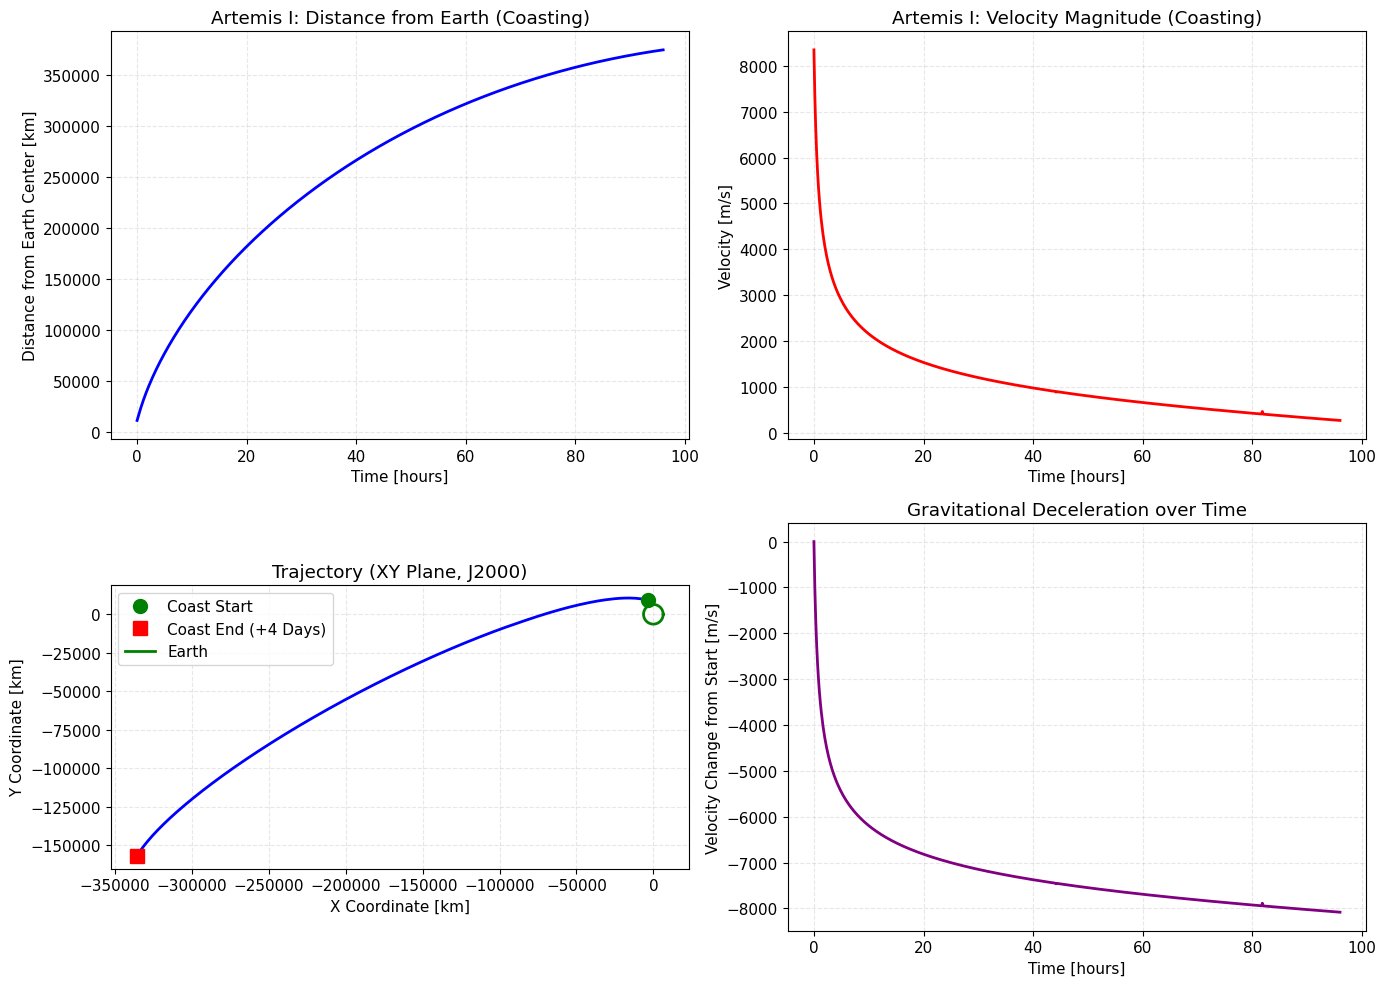

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plot_time_series(axes[0, 0], t_rel_hours, [r_mags], colors=['blue'], 
                 title='Artemis I: Distance from Earth (Coasting)', ylabel='Distance from Earth Center [km]')

plot_time_series(axes[0, 1], t_rel_hours, [v_mags * 1000], colors=['red'], 
                 title='Artemis I: Velocity Magnitude (Coasting)', ylabel='Velocity [m/s]')

markers = [
    (horizons_data['positions'][0, 0], horizons_data['positions'][0, 1], 'go', 10, 'Coast Start'),
    (horizons_data['positions'][-1, 0], horizons_data['positions'][-1, 1], 'rs', 10, 'Coast End (+4 Days)')
]
plot_orbit_xy(axes[1, 0], [horizons_data['positions'].T], colors=['blue'], markers=markers)

plot_time_series(axes[1, 1], t_rel_hours, [dv_accumulated], colors=['purple'], 
                 title='Gravitational Deceleration over Time', ylabel='Velocity Change from Start [m/s]')

plt.tight_layout()
plt.show()

In [22]:
print(f"Total velocity change due to gravity during 4-day window: {dv_accumulated[-1]:.1f} m/s")

Total velocity change due to gravity during 4-day window: -8083.8 m/s


Plot 1:
- altitude steadily increasing as it moves earth -> moon, curve is steep before and flattens as it slows down  

Plot 2:
- after TLI burn, orion is at ~8.3km/s, out of earth's gravity, sun is probably pulling it back and its slowing down (the bump on 82hrs is another burn performed for trajectory correction)

Plot 3:
- J2000 ref frame, top down view

Plot 4:
- cumulative velocity 

## Two Body Integrator 

The simplest dynamical model - point-mass Earth gravity only

$$\vec{a}_{2body} = -\frac{\mu_E}{r^3}\vec{r}$$

r: Position vector [km] (3,)  
mu: Gravitational parameter [km^3/s^2]

In [23]:
def accel_two_body(r, mu=MU_EARTH):
    r_mag = np.linalg.norm(r)
    a = -mu * r / (r_mag ** 3) #[km/s^2] (3,)
    return a

state0: Initial state [x, y, z, vx, vy, vz] in km, km/s  
t_span: (t0, tf) time span in seconds  
t_eval: Times at which to store solution  
rtol, atol: Integrator tolerances  

In [24]:
def propagate_two_body(state0, t_span, t_eval=None, rtol=1e-10, atol=1e-12):
    def equations_of_motion(t, state):
        r = state[0:3]
        v = state[3:6]
        a = accel_two_body(r)
        return np.concatenate([v, a])
    
    sol = solve_ivp( # Solve Initial Value Problem
        equations_of_motion, 
        t_span, 
        state0, 
        method='DOP853', #Runge-Kutta (Dormand-Prince 4th and 5th order)
        t_eval=t_eval,
        rtol=rtol, 
        atol=atol,
        dense_output=True #spline
    )
    return sol

### Run

In [25]:
# Test - propagate from first Horizons point to second to establish a baseline error

state0_test = np.concatenate([horizons_data['positions'][0], horizons_data['velocities'][0]])
print(f"s0: Test Coordinates (first position & velocity vector): {state0_test}")

dt_test = horizons_data['times_et'][1] - horizons_data['times_et'][0]
print(f"dt_test: delta t between first 2 data points: {dt_test}")

print(f"Start at position s0, assume only Earth's gravity exists, integrate forward in time for dt_test seconds")
sol_test = propagate_two_body(state0_test, (0, dt_test), t_eval=[dt_test])

# isolating our predicted 6D vector
# solver returns a solution object
# .y is a matrix columns =  time steps
#  [:, -1] extracts the final column, corresponds to the prediction at the end run
state_pred = sol_test.y[:, -1]
state_actual = np.concatenate([horizons_data['positions'][1], horizons_data['velocities'][1]])

print("Two-body baseline propagation (1-minute Post-TLI coast):")
# slicing out respective r and v coordinates and subtracting actual and predicted
# np.linalg.norm by default does L2 - euclidean
# print(f"  Two Body acc  : {np.linalg.norm(a_2body)*1000:.6f}")
print(f"  Position error: {np.linalg.norm(state_pred[0:3] - state_actual[0:3])*1000:.2f} m")
print(f"  Velocity error: {np.linalg.norm(state_pred[3:6] - state_actual[3:6])*1000:.4f} m/s")

s0: Test Coordinates (first position & velocity vector): [-3.17129585e+03  9.06116222e+03  5.59182213e+03 -7.76325581e+00
  2.22221349e+00  2.12251486e+00]
dt_test: delta t between first 2 data points: 600.0000001192093
Start at position s0, assume only Earth's gravity exists, integrate forward in time for dt_test seconds
Two-body baseline propagation (1-minute Post-TLI coast):
  Position error: 448.85 m
  Velocity error: 1.1021 m/s


In [26]:
# Setup exact time array from Horizons ground truth
t_start_et = horizons_data['times_et'][0]
t_eval_exact = horizons_data['times_et'] - t_start_et
coast_duration = t_eval_exact[-1]
t_hours = t_eval_exact / 3600

# Initial state from Horizons (08:47 UTC)
state0_coast = np.concatenate([horizons_data['positions'][0], horizons_data['velocities'][0]])

# Run the Two-Body propagation over the full 4 days
print("Running Full 4-Day Two-Body Simulation...")
sol_2body_full = propagate_two_body(
    state0=state0_coast,
    t_span=(0, coast_duration),
    t_eval=t_eval_exact # Force it to evaluate at the exact Horizons timestamps
)

# Calculate Residuals (Error)
r_simulated = sol_2body_full.y[0:3, :]
r_ground_truth = horizons_data['positions'].T # Transpose to match shape (3, N)

# Calculate distance error in km at each time step
position_error_km = np.linalg.norm(r_simulated - r_ground_truth, axis=0)

Running Full 4-Day Two-Body Simulation...


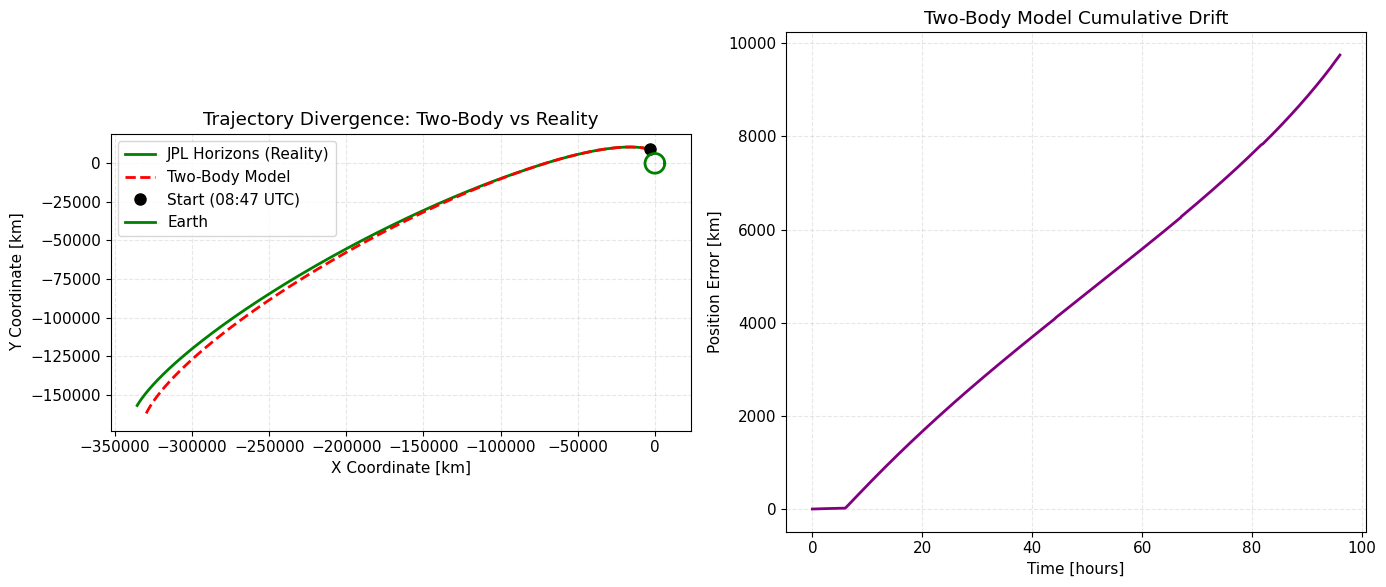

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

markers = [(state0_coast[0], state0_coast[1], 'ko', 8, 'Start (08:47 UTC)')]
plot_orbit_xy(axes[0], [r_ground_truth, r_simulated], labels=['JPL Horizons (Reality)', 'Two-Body Model'], 
              colors=['green', 'red'], styles=['-', '--'], title='Trajectory Divergence: Two-Body vs Reality', markers=markers)

plot_time_series(axes[1], t_hours, [position_error_km], colors=['purple'], 
                 title='Two-Body Model Cumulative Drift', ylabel='Position Error [km]')

plt.tight_layout()
plt.show()

In [28]:
print(f"Final position error after 4 days (Two-Body only): {position_error_km[-1]:.2f} km")

Final position error after 4 days (Two-Body only): 9747.82 km


Plot 1:
- top down 2D view of different trajectories, showing divergence of simplistic trajectory calculated with the one executed


Plot 2:
- shows positional error over time, at 96hrs (4 days) - ~10k km off

## J2 Oblateness Perturbation 

Earth's equatorial bulge causes the J2 perturbation, the dominant non spherical gravity term:

$$\vec{a}_{J2} = -\frac{3}{2} J_2 \mu_E \frac{R_E^2}{r^5} \begin{bmatrix} x(5\frac{z^2}{r^2} - 1) \\ y(5\frac{z^2}{r^2} - 1) \\ z(5\frac{z^2}{r^2} - 3) \end{bmatrix}$$

where $J_2 = 1.08263 \times 10^{-3}$

r: Position vector [km] (3,)  
mu: Gravitational parameter [km^3/s^2]  
j2: J2 coefficient  
r_eq: Equatorial radius [km]  

In [29]:
def accel_j2(r, mu=MU_EARTH, j2=J2_EARTH, r_eq=R_EARTH):
    x, y, z = r 
    # z=0, spacecraft directly above equator, if z is really large, its probably over the poles
    r_mag = np.linalg.norm(r)
    r2 = r_mag ** 2
    r5 = r_mag ** 5
    
    z2_r2 = (z ** 2) / r2
    
    # coeff = -1.5 * j2 * mu * (r_eq ** 2) / r5
    coeff = 1.5 * j2 * mu * (r_eq ** 2) / r5
    
    a_x = coeff * x * (5 * z2_r2 - 1)
    a_y = coeff * y * (5 * z2_r2 - 1)
    a_z = coeff * z * (5 * z2_r2 - 3)
    
    return np.array([a_x, a_y, a_z])


In [30]:
def accel_two_body_j2(r):
    return accel_two_body(r) + accel_j2(r)

In [31]:
def propagate_earth_j2(state0, t_span, t_eval, gravity_func, rtol=1e-10, atol=1e-12):
    def equations_of_motion(t, state):
        r = state[0:3]
        v = state[3:6]
        a = gravity_func(r)
        return np.concatenate([v, a])
    
    return solve_ivp(equations_of_motion, t_span, state0, method='DOP853', 
                     t_eval=t_eval, rtol=rtol, atol=atol)

### Run

In [32]:
# Test J2 magnitude at typical TLI altitude
r_test = horizons_data['positions'][0]
a_2body = accel_two_body(r_test)
a_j2 = accel_j2(r_test)

print("Acceleration comparison at initial position:")
print(f"  Two-body: {np.linalg.norm(a_2body)*1000:.6f} m/s² ({np.linalg.norm(a_2body)*1e6:.3f} mm/s²)")
print(f"  J2:       {np.linalg.norm(a_j2)*1e6:.6f} mm/s²")
print(f"  J2/2body ratio: {np.linalg.norm(a_j2)/np.linalg.norm(a_2body)*100:.4f}%")

Acceleration comparison at initial position:
  Two-body: 3.229358 m/s² (3229.358 mm/s²)
  J2:       1.559640 mm/s²
  J2/2body ratio: 0.0483%


In [33]:
r_test

masked_array(data=[-3171.29585472,  9061.16221995,  5591.82213079],
             mask=False,
       fill_value=1e+20)

In [34]:
# generic propagator that accepts gravity function

# initial conditions ( the first point of Horizons data)
state0_coast = np.concatenate([horizons_data['positions'][0], horizons_data['velocities'][0]])

# simulate the first 24 hours of the coast to the Moon
coast_duration = 24 * 3600  # seconds
t_eval_j2 = np.linspace(0, coast_duration, 500)

# Run Simulation A: Pure Two-Body (Perfect Sphere)
print("Running Two-Body Baseline...")
sol_2body = propagate_earth_j2(state0_coast, (0, coast_duration), t_eval_j2, accel_two_body)

# Run Simulation B: Two-Body + J2 (Bulging Earth)
print("Running J2 Perturbation Model...")
sol_j2 = propagate_earth_j2(state0_coast, (0, coast_duration), t_eval_j2, accel_two_body_j2)

# Calculate the divergence (How far apart are the two simulated spacecraft?)
r_2body = sol_2body.y[0:3, :]
r_j2 = sol_j2.y[0:3, :]
divergence_km = np.linalg.norm(r_j2 - r_2body, axis=0)

# Calculate the raw strength of J2 over time
j2_accel_mags = [np.linalg.norm(accel_j2(r)) * 1e6 for r in r_j2.T] # Convert to mm/s²


Running Two-Body Baseline...
Running J2 Perturbation Model...


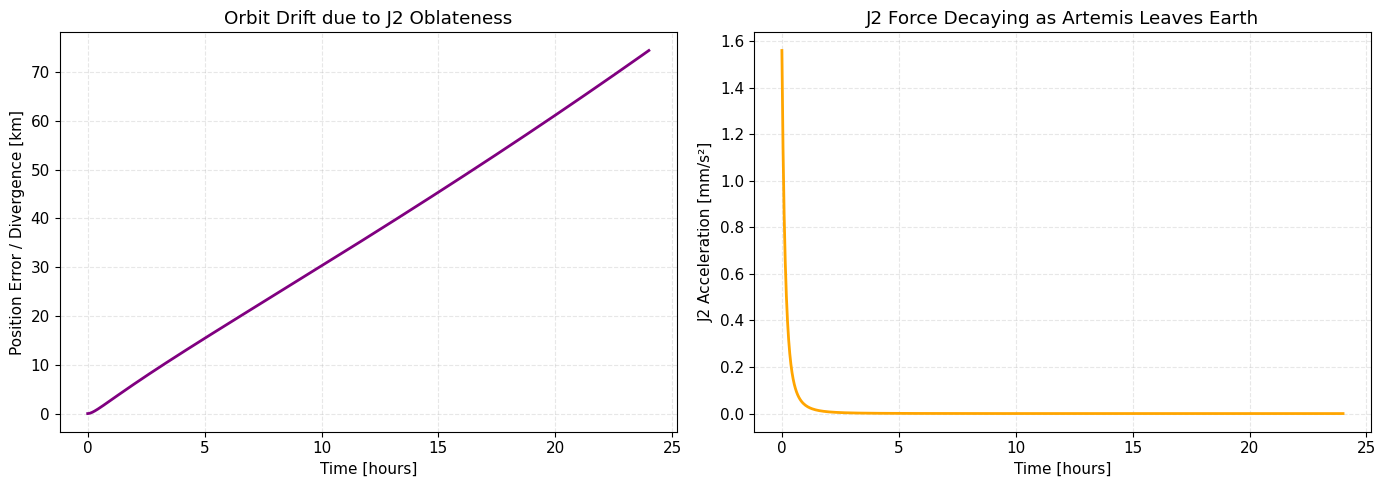


Total position error after 24 hours if J2 is ignored: 74.38 km


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: The Compounding Error
plot_time_series(axes[0], t_eval_j2 / 3600, [divergence_km], colors=['purple'], 
                 title='Orbit Drift due to J2 Oblateness', 
                 ylabel='Position Error / Divergence [km]')

# Plot 2: The J2 Decay
plot_time_series(axes[1], t_eval_j2 / 3600, [j2_accel_mags], colors=['orange'], 
                 title='J2 Force Decaying as Artemis Leaves Earth', 
                 ylabel='J2 Acceleration [mm/s²]')

plt.tight_layout()
plt.show()

print(f"\nTotal position error after 24 hours if J2 is ignored: {divergence_km[-1]:.2f} km")

Plot1 -  
- That means in 24hrs, the estimate from this model would be ~ 75km away from where its observed to be
Plot 2 - 
- gravity (J2) decays at 1/r^4 at hour 5 - but after we exit LEO, earth kind of behaves like a point mass

## Third-Body Perturbations 

Moon and Sun gravity make this an n-body problem, 3rd body acc. uses the indirect term:

$$\vec{a}_{3B} = \mu_{body}\left(\frac{\vec{r}_{body \to s/c}}{|\vec{r}_{body \to s/c}|^3} - \frac{\vec{r}_{body \to Earth}}{|\vec{r}_{body \to Earth}|^3}\right)$$

SPICE provides precise planetary positions
(times in ET, not UTC)

r_sc: Spacecraft position wrt central body [km] (3,)  
r_body: Third body position wrt central body [km] (3,)  
mu_body: Third body gravitational parameter [km^3/s^2]  

In [36]:
def accel_third_body(r_sc, r_body, mu_body):
    # Direct Term: Acceleration of Spacecraft toward Third Body
    r_body_to_sc = r_sc - r_body
    a_direct = -mu_body * (r_body_to_sc / np.linalg.norm(r_body_to_sc)**3)
    
    # Indirect Term: Acceleration of Earth toward Third Body
    a_indirect = mu_body * (r_body / np.linalg.norm(r_body)**3)
    
    # Relative Acceleration: Spacecraft minus Earth
    return a_direct - a_indirect

In [37]:
# Moon third-body perturbation
def accel_moon(r_sc, et):
    r_moon = get_body_position_spice(301, 399, et)  # Moon wrt Earth
    return accel_third_body(r_sc, r_moon, MU_MOON)

# Sun third-body perturbation
def accel_sun(r_sc, et):
    r_sun = get_body_position_spice(10, 399, et)  # Sun wrt Earth
    return accel_third_body(r_sc, r_sun, MU_SUN)

In [38]:
def propagate_nbody(state0, t_span, t_eval, et_start):
    def equations_of_motion(t, state):
        r = state[0:3]
        v = state[3:6]
        current_et = et_start + t # SPICE needs the exact current time
        
        # Calculate all forces
        a_earth = accel_two_body_j2(r) # Earth + Bulge
        a_m = accel_moon(r, current_et) # Moon
        a_s = accel_sun(r, current_et)  # Sun
        
        return np.concatenate([v, a_earth + a_m + a_s])
    
    return solve_ivp(equations_of_motion, t_span, state0, method='DOP853', 
                     t_eval=t_eval, rtol=1e-10, atol=1e-12)

### Run

In [39]:
# Test third-body accelerations at TLI
et_test = utc_to_et(TLI_START_UTC)
r_test = horizons_data['positions'][idx_ignition]

a_moon = accel_moon(r_test, et_test)
a_sun = accel_sun(r_test, et_test)

print("Third-body accelerations at TLI ignition:")
print(f"  Moon: {np.linalg.norm(a_moon)*1e9:.3f} nm/s² (direction: [{a_moon[0]/np.linalg.norm(a_moon):.3f}, {a_moon[1]/np.linalg.norm(a_moon):.3f}, {a_moon[2]/np.linalg.norm(a_moon):.3f}])")
print(f"  Sun:  {np.linalg.norm(a_sun)*1e9:.3f} nm/s²")
print(f"  Moon/J2 ratio: {np.linalg.norm(a_moon)/np.linalg.norm(accel_j2(r_test))*100:.4f}%")

# Moon position check
r_moon = get_body_position_spice(301, 399, et_test)
print(f"\nMoon distance from Earth: {np.linalg.norm(r_moon):.0f} km")

Third-body accelerations at TLI ignition:
  Moon: 1.506 nm/s² (direction: [-0.943, 0.282, 0.175])
  Sun:  0.653 nm/s²
  Moon/J2 ratio: 0.0966%

Moon distance from Earth: 402232 km


In [40]:
# Setup the 4-day coast timeline (using actual empirical data start time)
t_start_et = horizons_data['times_et'][0]
coast_duration_4days = 4 * 24 * 3600  # 4 days in seconds
t_eval_4days = np.linspace(0, coast_duration_4days, 1000)
state0_coast = np.concatenate([horizons_data['positions'][0], horizons_data['velocities'][0]])

In [41]:
print("Running J2-Only Baseline (4 Days)...")
sol_j2_only = propagate_earth_j2(state0_coast, (0, coast_duration_4days), t_eval_4days, accel_two_body_j2)

print("Running Full N-Body Simulation (Earth + J2 + Moon + Sun)...")
sol_nbody = propagate_nbody(state0_coast, (0, coast_duration_4days), t_eval_4days, t_start_et)

Running J2-Only Baseline (4 Days)...
Running Full N-Body Simulation (Earth + J2 + Moon + Sun)...


In [42]:
# Calculate Divergence and Lunar Gravity Strength
r_j2 = sol_j2_only.y[0:3, :]
r_nbody = sol_nbody.y[0:3, :]
divergence_nbody_km = np.linalg.norm(r_nbody - r_j2, axis=0)

# Calculate how strong the Moon's pull gets over the 4 days
moon_accel_mags = [np.linalg.norm(accel_moon(r_nbody[:, i], t_start_et + t_eval_4days[i])) * 1e6 
                   for i in range(len(t_eval_4days))] # in mm/s^2

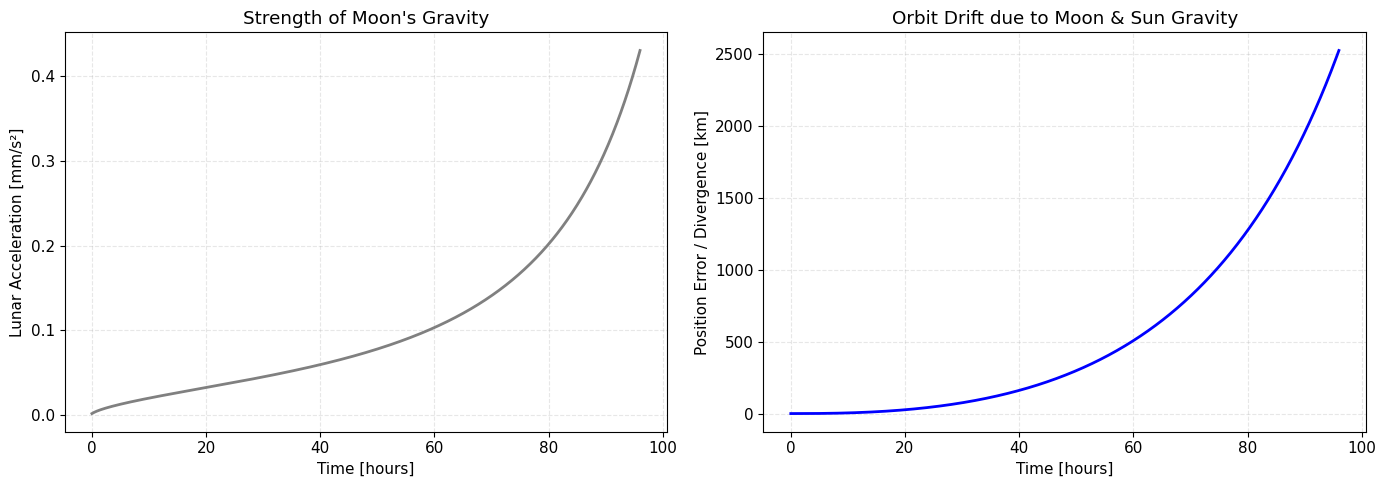

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_time_series(axes[0], t_eval_4days / 3600, [moon_accel_mags], colors=['gray'], 
                 title="Strength of Moon's Gravity", ylabel='Lunar Acceleration [mm/s²]')

plot_time_series(axes[1], t_eval_4days / 3600, [divergence_nbody_km], colors=['blue'], 
                 title='Orbit Drift due to Moon & Sun Gravity', ylabel='Position Error / Divergence [km]')

plt.tight_layout()
plt.show()

In [44]:
print(f"Total position error after 4 days if Moon/Sun are ignored: {divergence_nbody_km[-1]:.2f} km")

Total position error after 4 days if Moon/Sun are ignored: 2527.79 km


Plot 1 -  
- For the first 40 hours, Earth's gravity is completely overwhelming the Moon's gravity, so the gray line stays relatively flat. But as Orion crosses the halfway point, the distance r to the Moon rapidly shrinks   
- By Hour 80, the line violently curves upward - Lunar Sphere of Influence (SOI)

Plot 2 - 
- radius of the Moon is roughly 1,737 km
- Artemis I was targeting a highly precise flyby altitude of just 130 km above the lunar surface
- If a mission planner used a simple Earth-only Two-Body model and ignored the Moon and Sun, their math would put them 2,500 km off targe

## Solar Radiation Pressure

The cannonball SRP model assumes a spherical spacecraft:

$$\vec{a}_{SRP} = -C_r \frac{A}{m} \frac{\Phi}{c} \left(\frac{1 AU}{r_{sun}}\right)^2 \hat{s}$$

where $\hat{s}$ is the unit vector from spacecraft to Sun.

Eclipse shadowing is included (SRP = 0 when spacecraft is in Earth's shadow).

r_sc: Spacecraft position wrt Earth [km]  
r_sun: Sun position wrt Earth [km]  
r_body: Shadow-casting body radius [km]  
shadow_factor: 1.0 = full sun, 0.0 = full shadow  

In [45]:
def is_in_shadow(r_sc, r_sun, r_body=R_EARTH):
    # Unit vector from Earth to Sun
    r_sun_mag = np.linalg.norm(r_sun)
    sun_hat = r_sun / r_sun_mag
    
    # Project spacecraft position onto Sun direction
    proj = np.dot(r_sc, sun_hat)
    
    # If spacecraft is on Sun side, not in shadow
    if proj > 0:
        return 1.0
    
    # Perpendicular distance from shadow axis
    perp = r_sc - proj * sun_hat
    perp_dist = np.linalg.norm(perp)
    
    # Simple cylindrical shadow
    if perp_dist < r_body:
        return 0.0
    
    return 1.0

r_sc: Spacecraft position wrt Earth [km]  
mass: Spacecraft mass [kg]  
et: Ephemeris time  
cr: Reflectivity coefficient  
area: Cross-sectional area [m^2]  

In [46]:
def accel_srp(r_sc, mass, et, cr=CR_SRP, area=ORION_AREA):
    # Sun position wrt Earth
    r_sun_earth = get_body_position_spice(10, 399, et)
    
    # Spacecraft to Sun vector
    r_sc_to_sun = r_sun_earth - r_sc
    r_sc_sun_mag = np.linalg.norm(r_sc_to_sun)
    sun_hat = r_sc_to_sun / r_sc_sun_mag
    
    # Check shadow
    shadow = is_in_shadow(r_sc, r_sun_earth)
    if shadow == 0:
        return np.zeros(3)
    
    # SRP pressure at 1 AU: P = Phi/c
    # Phi = 1367 W/m^2, c = 299792458 m/s
    # P_1AU = 1367 / 299792458 = 4.56e-6 N/m^2
    P_1AU = SOLAR_FLUX / (C_LIGHT * 1000)  # N/m^2 (c in m/s)
    
    # Scale by distance
    r_sc_sun_au = r_sc_sun_mag / AU_KM
    P = P_1AU / (r_sc_sun_au ** 2)
    
    # Acceleration: a = Cr * P * A / m
    # Units: a [m/s^2] = Cr * P [N/m^2] * A [m^2] / m [kg]
    a_mag = cr * P * area / mass  # m/s^2
    a_mag_km = a_mag / 1000.0  # km/s^2
    
    # Direction: away from Sun
    # SRP acceleration [km/s^2]
    return -a_mag_km * sun_hat * shadow

In [47]:
def propagate_srp(state0, t_span, t_eval, et_start, mass, include_srp=True):
    def equations_of_motion(t, state):
        r = state[0:3]
        v = state[3:6]
        current_et = et_start + t

        r_sun = get_body_position_spice(10, 399, current_et)
        r_moon = get_body_position_spice(301, 399, current_et)

        a_earth = accel_two_body_j2(r)
        a_moon = accel_third_body(r, r_moon, MU_MOON)
        a_sun = accel_third_body(r, r_sun, MU_SUN)
        a_srp_force = accel_srp(r, mass, current_et) if include_srp else np.zeros(3)

        # The sum of all forces acting on the spacecraft
        return np.concatenate([v, a_earth + a_moon + a_sun + a_srp_force])

    return solve_ivp(equations_of_motion, t_span, state0, method='DOP853',
                     t_eval=t_eval, rtol=1e-10, atol=1e-12)

### Run

In [48]:
a_srp_test = accel_srp(r_test, ORION_MASS_INITIAL, et_test)
print(f"SRP acceleration at TLI: {np.linalg.norm(a_srp_test)*1e12:.3f} pm/s²")
print(f"SRP/Moon ratio: {np.linalg.norm(a_srp_test)/np.linalg.norm(a_moon)*100:.4f}%")
print(f"Shadow factor: {is_in_shadow(r_test, get_body_position_spice(10, 399, et_test))}")

SRP acceleration at TLI: 6.596 pm/s²
SRP/Moon ratio: 0.4380%
Shadow factor: 1.0


In [49]:
t_start_et = horizons_data['times_et'][0]
coast_duration = 4 * 24 * 3600  # 4 days in seconds
t_eval_srp = np.linspace(0, coast_duration, 1000)
state0_coast = np.concatenate([horizons_data['positions'][0], horizons_data['velocities'][0]])

In [50]:
# We use the final mass AFTER the engine burn for the coasting phase
COASTING_MASS =   30480.0 # [kg] 

In [51]:
print("Running N-Body Baseline (Gravity Only)...")
sol_no_srp = propagate_srp(state0_coast, (0, coast_duration), t_eval_srp, t_start_et, COASTING_MASS, include_srp=False)

print("Running N-Body + SRP (Full Physics)...")
sol_with_srp = propagate_srp(state0_coast, (0, coast_duration), t_eval_srp, t_start_et, COASTING_MASS, include_srp=True)

# Calculate Divergence
r_no_srp = sol_no_srp.y[0:3, :]
r_with_srp = sol_with_srp.y[0:3, :]
divergence_srp_km = np.linalg.norm(r_with_srp - r_no_srp, axis=0)

# Calculate raw SRP magnitude over time
srp_accel_mags = [np.linalg.norm(accel_srp(r_with_srp[:, i], COASTING_MASS, t_start_et + t_eval_srp[i])) * 1e9 
                  for i in range(len(t_eval_srp))] # converted to nm/s^2

Running N-Body Baseline (Gravity Only)...
Running N-Body + SRP (Full Physics)...


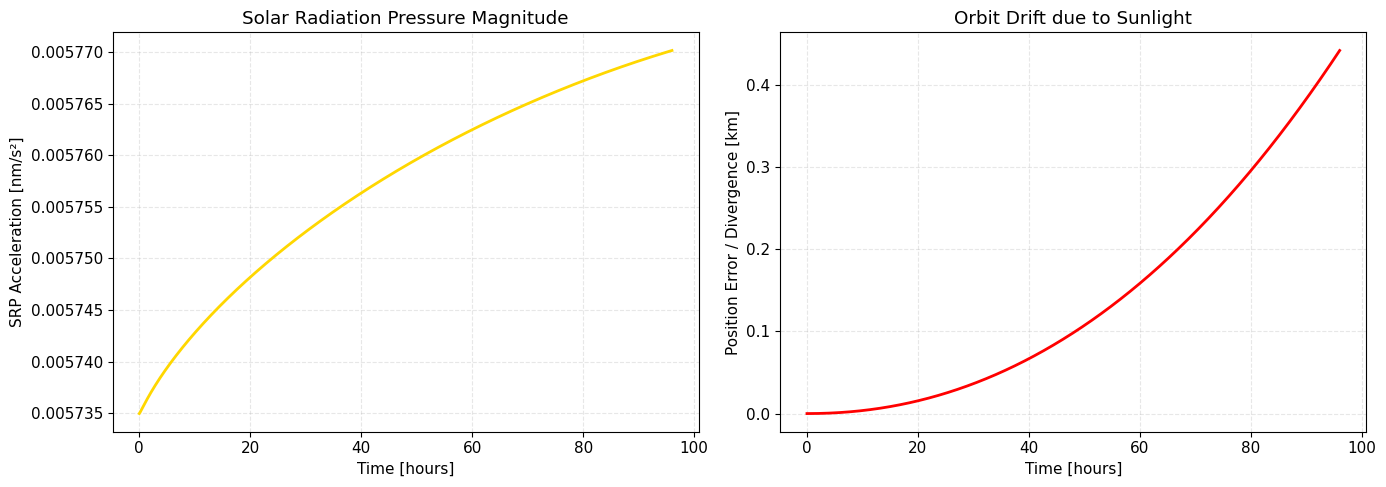

Total position drift after 4 days strictly due to sunlight: 0.442 km


In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: The Push of Sunlight
plot_time_series(axes[0], t_eval_srp / 3600, [srp_accel_mags], colors=['gold'], 
                 title='Solar Radiation Pressure Magnitude', 
                 ylabel='SRP Acceleration [nm/s²]')

# Plot 2: Trajectory Divergence due to Light
plot_time_series(axes[1], t_eval_srp / 3600, [divergence_srp_km], colors=['red'], 
                 title='Orbit Drift due to Sunlight', 
                 ylabel='Position Error / Divergence [km]')

plt.tight_layout()
plt.show()

print(f"Total position drift after 4 days strictly due to sunlight: {divergence_srp_km[-1]:.3f} km")

Plot 1 -  
- the total force of sunlight pushing against the 30,000 kg Artemis spacecraft is roughly equivalent to the weight of a single snowflake resting on the palm around 0.0057 nm/s²
- The slight upward curve just means the Earth-Moon system is moving marginally closer to the Sun  

Plot 2 - 
- over 4 days this tiny affect actually moves the spacecraft ~0.45 km

## Lunar J2 Moon's Oblateness

In [53]:
def accel_j2_moon(r_sc, et):
    r_moon = get_body_position_spice(301, 399, et)
    # r_sc_moon = r_sc - r_moon
    # return accel_j2(r_sc_moon, mu=MU_MOON, j2=J2_MOON, r_eq=R_MOON)
    r_sc_moon_j2000 = r_sc - r_moon

    # J2 must be computed in the body-fixed frame, not inertial J2000.
    rot_j2000_to_moon = spice.pxform('J2000', 'IAU_MOON', et)
    rot_moon_to_j2000 = spice.pxform('IAU_MOON', 'J2000', et)

    r_sc_moon_fixed = rot_j2000_to_moon @ r_sc_moon_j2000
    a_j2_fixed = accel_j2(r_sc_moon_fixed, mu=MU_MOON, j2=J2_MOON, r_eq=R_MOON)
    return rot_moon_to_j2000 @ a_j2_fixed

In [54]:
def propagate_moon_j2(state0, t_span, t_eval, et_start, mass):
    def eom(t, state):
        r, v = state[0:3], state[3:6]
        et = et_start + t
        a = (accel_two_body_j2(r) + accel_moon(r, et) + accel_sun(r, et) + 
             accel_srp(r, mass, et) + accel_j2_moon(r, et))
        return np.concatenate([v, a])

    return solve_ivp(eom, t_span, state0, method='DOP853', t_eval=t_eval, rtol=1e-10, atol=1e-12)

### Run

In [55]:
# Isolate the final 24-hour window using the SRP simulation from the previous step
t_cutoff = max(0, t_eval_srp[-1] - 24 * 3600)
idx_start = np.argmax(t_eval_srp >= t_cutoff)  # Finds the first index inside the 24h window

t_eval_last24 = t_eval_srp[idx_start:]
state_last24 = sol_with_srp.y[:, idx_start]

# Setup shifted time variables (to start at t=0 for the integrator)
t_shift = t_eval_last24[0]
t_eval_shifted = t_eval_last24 - t_shift
et_start_shifted = t_start_et + t_shift
t_span = (0, t_eval_shifted[-1])

# Propagate both models from this new 24-hour starting point for an apples-to-apples comparison
sol_ult_last24 = propagate_srp(state_last24, t_span, t_eval_shifted, et_start_shifted, COASTING_MASS, include_srp=True)
sol_super_last24 = propagate_moon_j2(state_last24, t_span, t_eval_shifted, et_start_shifted, COASTING_MASS)

# Calculate divergence between the model with Lunar J2 and without
r_ult_last24 = sol_ult_last24.y[0:3, :]
r_super_last24 = sol_super_last24.y[0:3, :]
div_super_km = np.linalg.norm(r_super_last24 - r_ult_last24, axis=0)

# Calculate Lunar J2 Acceleration over this window
j2_moon_accel = np.array([
    np.linalg.norm(accel_j2_moon(r, t_start_et + t)) * 1e6 
    for r, t in zip(r_super_last24.T, t_eval_last24)
])

time_last24_hr = t_eval_shifted / 3600.0

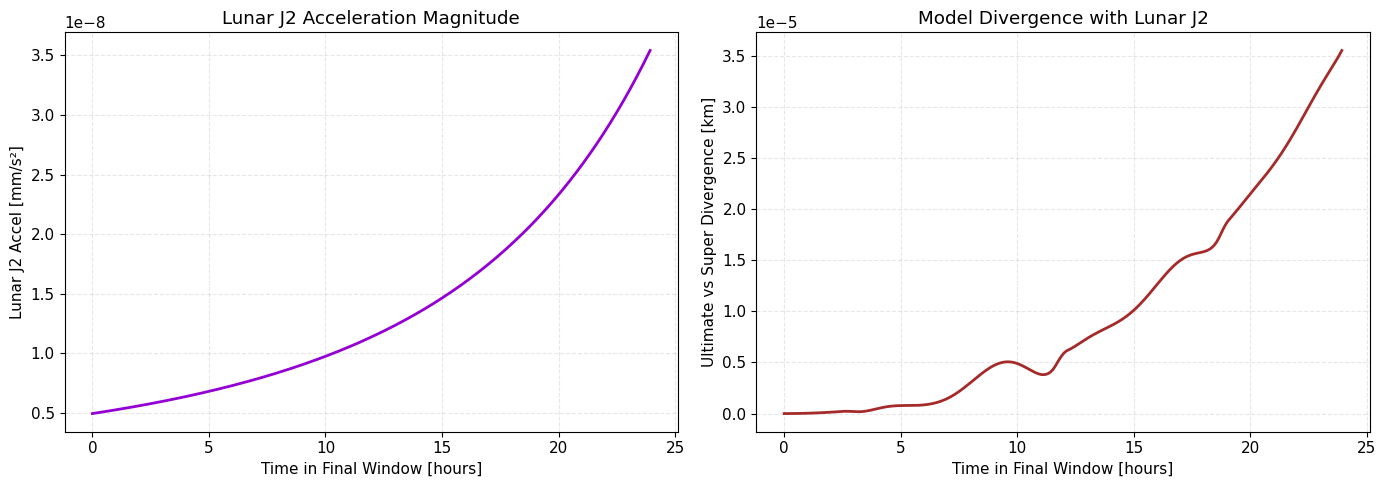

Peak Lunar J2 acceleration in final window: 0.000000 mm/s²
Final Ultimate-vs-Super divergence: 0.000036 km


In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: The Lunar J2 Acceleration
plot_time_series(axes[0], time_last24_hr, [j2_moon_accel], colors=['darkviolet'], 
                 title='Lunar J2 Acceleration Magnitude', 
                 xlabel='Time in Final Window [hours]',
                 ylabel='Lunar J2 Accel [mm/s²]')

# Plot 2: Model Divergence with Lunar J2
plot_time_series(axes[1], time_last24_hr, [div_super_km], colors=['brown'], 
                 title='Model Divergence with Lunar J2', 
                 xlabel='Time in Final Window [hours]',
                 ylabel='Ultimate vs Super Divergence [km]')

plt.tight_layout()
plt.show()

print(f"Peak Lunar J2 acceleration in final window: {np.max(j2_moon_accel):.6f} mm/s²")
print(f"Final Ultimate-vs-Super divergence: {div_super_km[-1]:.6f} km")

only 3.2cm displacement over 24 hrs

## Ultimate Model vs JPL Horizons Ground Truth

In [ ]:
# Setup exact timestamps and ground truth data
t_eval_exact = horizons_data['times_et'] - t_start_et
h_pos = horizons_data['positions']
h_vel = horizons_data['velocities']
time_hours = t_eval_exact / 3600.0

# Extract Moon distance
moon_dist = horizons_data.get('moon_distances')

# Propagate all intermediate models at the exact Horizons timestamps
sol_2body_exact = propagate_two_body(state0_test, (0, dt_test), t_eval=[dt_test])
sol_j2_exact = propagate_earth_j2(state0_coast, (0, t_eval_exact[-1]), t_eval_exact, accel_two_body_j2)
sol_nbody_exact = propagate_nbody(state0_coast, (0, t_eval_exact[-1]), t_eval_exact, t_start_et)
sol_ult_exact = propagate_srp(state0_coast, (0, t_eval_exact[-1]), t_eval_exact, t_start_et, COASTING_MASS, include_srp=True)

# Calculate position errors against Horizons for each model
error_2body = np.linalg.norm(sol_2body_exact.y[0:3, :].T - h_pos, axis=1)
error_j2    = np.linalg.norm(sol_j2_exact.y[0:3, :].T - h_pos, axis=1)
error_nbody = np.linalg.norm(sol_nbody_exact.y[0:3, :].T - h_pos, axis=1)
error_ult   = np.linalg.norm(sol_ult_exact.y[0:3, :].T - h_pos, axis=1)

velmag_ultimate = np.linalg.norm(sol_ult_exact.y[3:6, :], axis=0)
velmag_horizons = np.linalg.norm(h_vel, axis=1)

Propagating models for exact comparison...


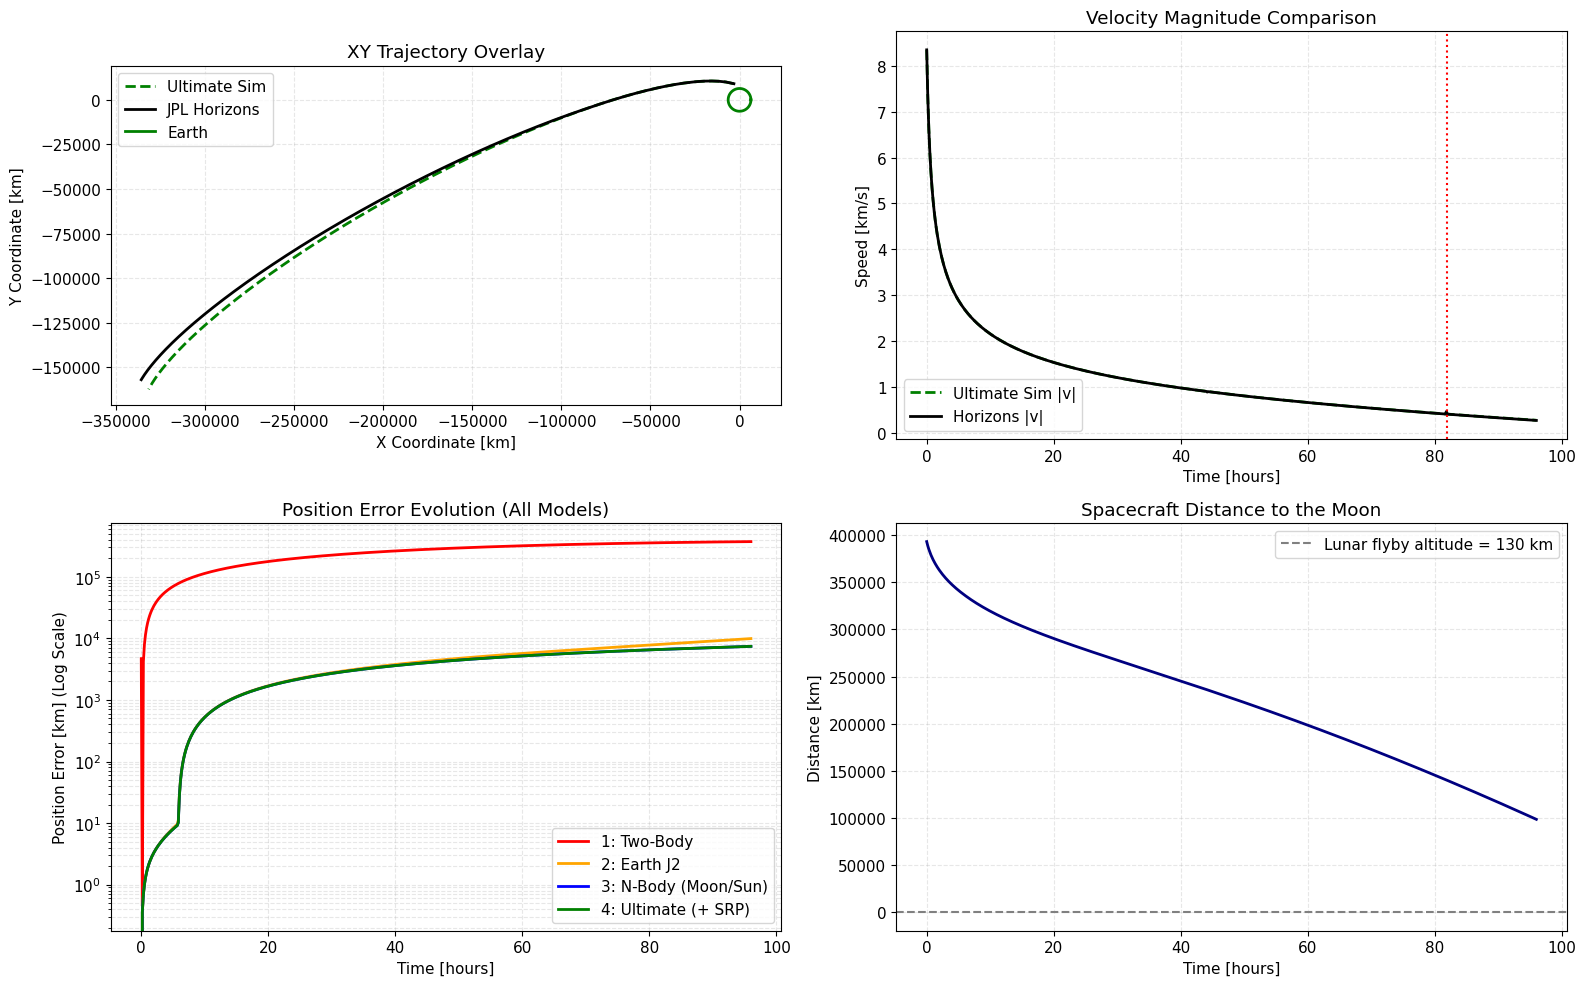

Final ultimate-vs-Horizons error: 7426.285 km


In [73]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot A: XY Trajectory Overlay
plot_orbit_xy(
    axes[0, 0], 
    pos_list=[sol_ult_exact.y[0:3, :], h_pos.T], 
    labels=['Ultimate Sim', 'JPL Horizons'], 
    colors=['green', 'black'], 
    styles=['--', '-'], 
    title='XY Trajectory Overlay', 
    plot_earth=True
)

# Plot B: Velocity Magnitude Comparison
vlines = [(82.0, 'red', ':', 1.0)] # 82 hr TCM candidate line
plot_time_series(
    axes[0, 1], time_hours, 
    y_list=[velmag_ultimate, velmag_horizons], 
    labels=['Ultimate Sim |v|', 'Horizons |v|'],
    colors=['green', 'black'], styles=['--', '-'], 
    title='Velocity Magnitude Comparison', ylabel='Speed [km/s]', vlines=vlines
)

# Plot C: Position Error for ALL Models (Log Scale)
plot_time_series(
    axes[1, 0], time_hours, 
    y_list=[error_2body, error_j2, error_nbody, error_ult], 
    labels=['1: Two-Body', '2: Earth J2', '3: N-Body (Moon/Sun)', '4: Ultimate (+ SRP)'],
    colors=['red', 'orange', 'blue', 'green'], 
    styles=['-', '-', '-', '-'], 
    title='Position Error Evolution (All Models)', 
    ylabel='Position Error [km] (Log Scale)', yscale='log'
)

# Plot D: Distance to the Moon
hlines = [(130.0, 'gray', '--', 'Lunar flyby altitude = 130 km')]
plot_time_series(
    axes[1, 1], time_hours, 
    y_list=[moon_dist], 
    colors=['navy'], 
    title='Spacecraft Distance to the Moon', 
    ylabel='Distance [km]', hlines=hlines
)

plt.tight_layout()
plt.savefig(f"{plot_dir}/all_models_vs_horizons.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Final ultimate-vs-Horizons error: {error_ult[-1]:.3f} km")